# 07 - Final Evaluation for Late Fusion Architecture

This notebook performs final evaluation on the held-out test set for the Late Fusion model:
1. Load all three models (genomic, clinical, late fusion)
2. Evaluate on untouched test data
3. Generate publication-quality figures (ROC, PR, Calibration, Confusion Matrix)
4. Compare all three models

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

import config
from src.io import load_model, save_table, save_figure, logger
from src.models import xgb_safe_frame
from src.clinical_engineer import create_clinical_features
from src.visualization import setup_style

setup_style()

## Step 1: Load Models and Data

In [2]:
print("Loading Late Fusion models...")

genomic_model = load_model("genomic_model.joblib")
clinical_model = load_model("clinical_model.joblib")
fusion_predictor = load_model("late_fusion_predictor.joblib")

print(f"Genomic model loaded: {type(genomic_model).__name__}")
print(f"Clinical model loaded: {type(clinical_model).__name__}")
print(f"Fusion weights: genomic={fusion_predictor.genomic_weight:.3f}, clinical={fusion_predictor.clinical_weight:.3f}")

2026-09-11 19:18:14 | INFO     | prostate_bcr | Loading model from D:\Prostate_BCR\core\outputs\models\genomic_model.joblib
2026-09-11 19:18:14 | INFO     | prostate_bcr | Loading model from D:\Prostate_BCR\core\outputs\models\clinical_model.joblib
2026-09-11 19:18:14 | INFO     | prostate_bcr | Loading model from D:\Prostate_BCR\core\outputs\models\late_fusion_predictor.joblib


Loading Late Fusion models...
Genomic model loaded: XGBClassifier
Clinical model loaded: XGBClassifier
Fusion weights: genomic=0.610, clinical=0.390


In [3]:
X_test_raw = pd.read_csv(config.PROCESSED_DIR / "X_test_preprocessed.csv")
y_test = pd.read_csv(config.PROCESSED_DIR / "y_test.csv").iloc[:, 0]

genomic_features_df = pd.read_csv(config.TABLES_DIR / "final_genomic_features.csv")
genomic_features = genomic_features_df["feature"].tolist()

clinical_features_df = pd.read_csv(config.TABLES_DIR / "final_clinical_features.csv")
clinical_features = clinical_features_df["feature"].tolist()

print(f"Genomic features: {len(genomic_features)}")
print(f"Clinical features: {len(clinical_features)}")
print(f"Test samples: {len(y_test)}")

X_test_genomic = X_test_raw[genomic_features].copy()
X_test_genomic_safe = xgb_safe_frame(X_test_genomic)

X_test_clinical, _ = create_clinical_features(X_test_raw)
X_test_clinical = X_test_clinical[clinical_features].copy()

logger.info(f"Test data prepared: {X_test_genomic.shape[0]} samples")

2026-09-11 19:18:22 | INFO     | prostate_bcr | Clinical: Gleason_Total, High_Risk_Gleason
2026-09-11 19:18:22 | INFO     | prostate_bcr | Clinical: Margin_x_LymphNode
2026-09-11 19:18:22 | INFO     | prostate_bcr | Clinical: T_Stage_Risk
2026-09-11 19:18:22 | INFO     | prostate_bcr | Clinical: PSA_Pathway_Score (from 7 genes)
2026-09-11 19:18:22 | INFO     | prostate_bcr | Clinical: AR_Signaling_Score (from 8 genes)
2026-09-11 19:18:22 | INFO     | prostate_bcr | Clinical: Proliferation_Score (from 7 genes)
2026-09-11 19:18:22 | INFO     | prostate_bcr | Test data prepared: 86 samples


Genomic features: 40
Clinical features: 14
Test samples: 86


## Step 2: Generate Predictions from All Models

In [4]:
y_prob_genomic = genomic_model.predict_proba(X_test_genomic_safe)[:, 1]
y_prob_clinical = clinical_model.predict_proba(X_test_clinical)[:, 1]
y_prob_fusion = fusion_predictor.predict_proba(X_test_genomic, X_test_clinical)[:, 1]

print("Predictions generated for all three models")
print(f"Genomic AUC: {roc_auc_score(y_test, y_prob_genomic):.4f}")
print(f"Clinical AUC: {roc_auc_score(y_test, y_prob_clinical):.4f}")
print(f"Fusion AUC: {roc_auc_score(y_test, y_prob_fusion):.4f}")

Predictions generated for all three models
Genomic AUC: 0.7579
Clinical AUC: 0.7832
Fusion AUC: 0.8401


## Step 3: ROC Curves Comparison

2026-09-11 19:18:40 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\roc_comparison.png


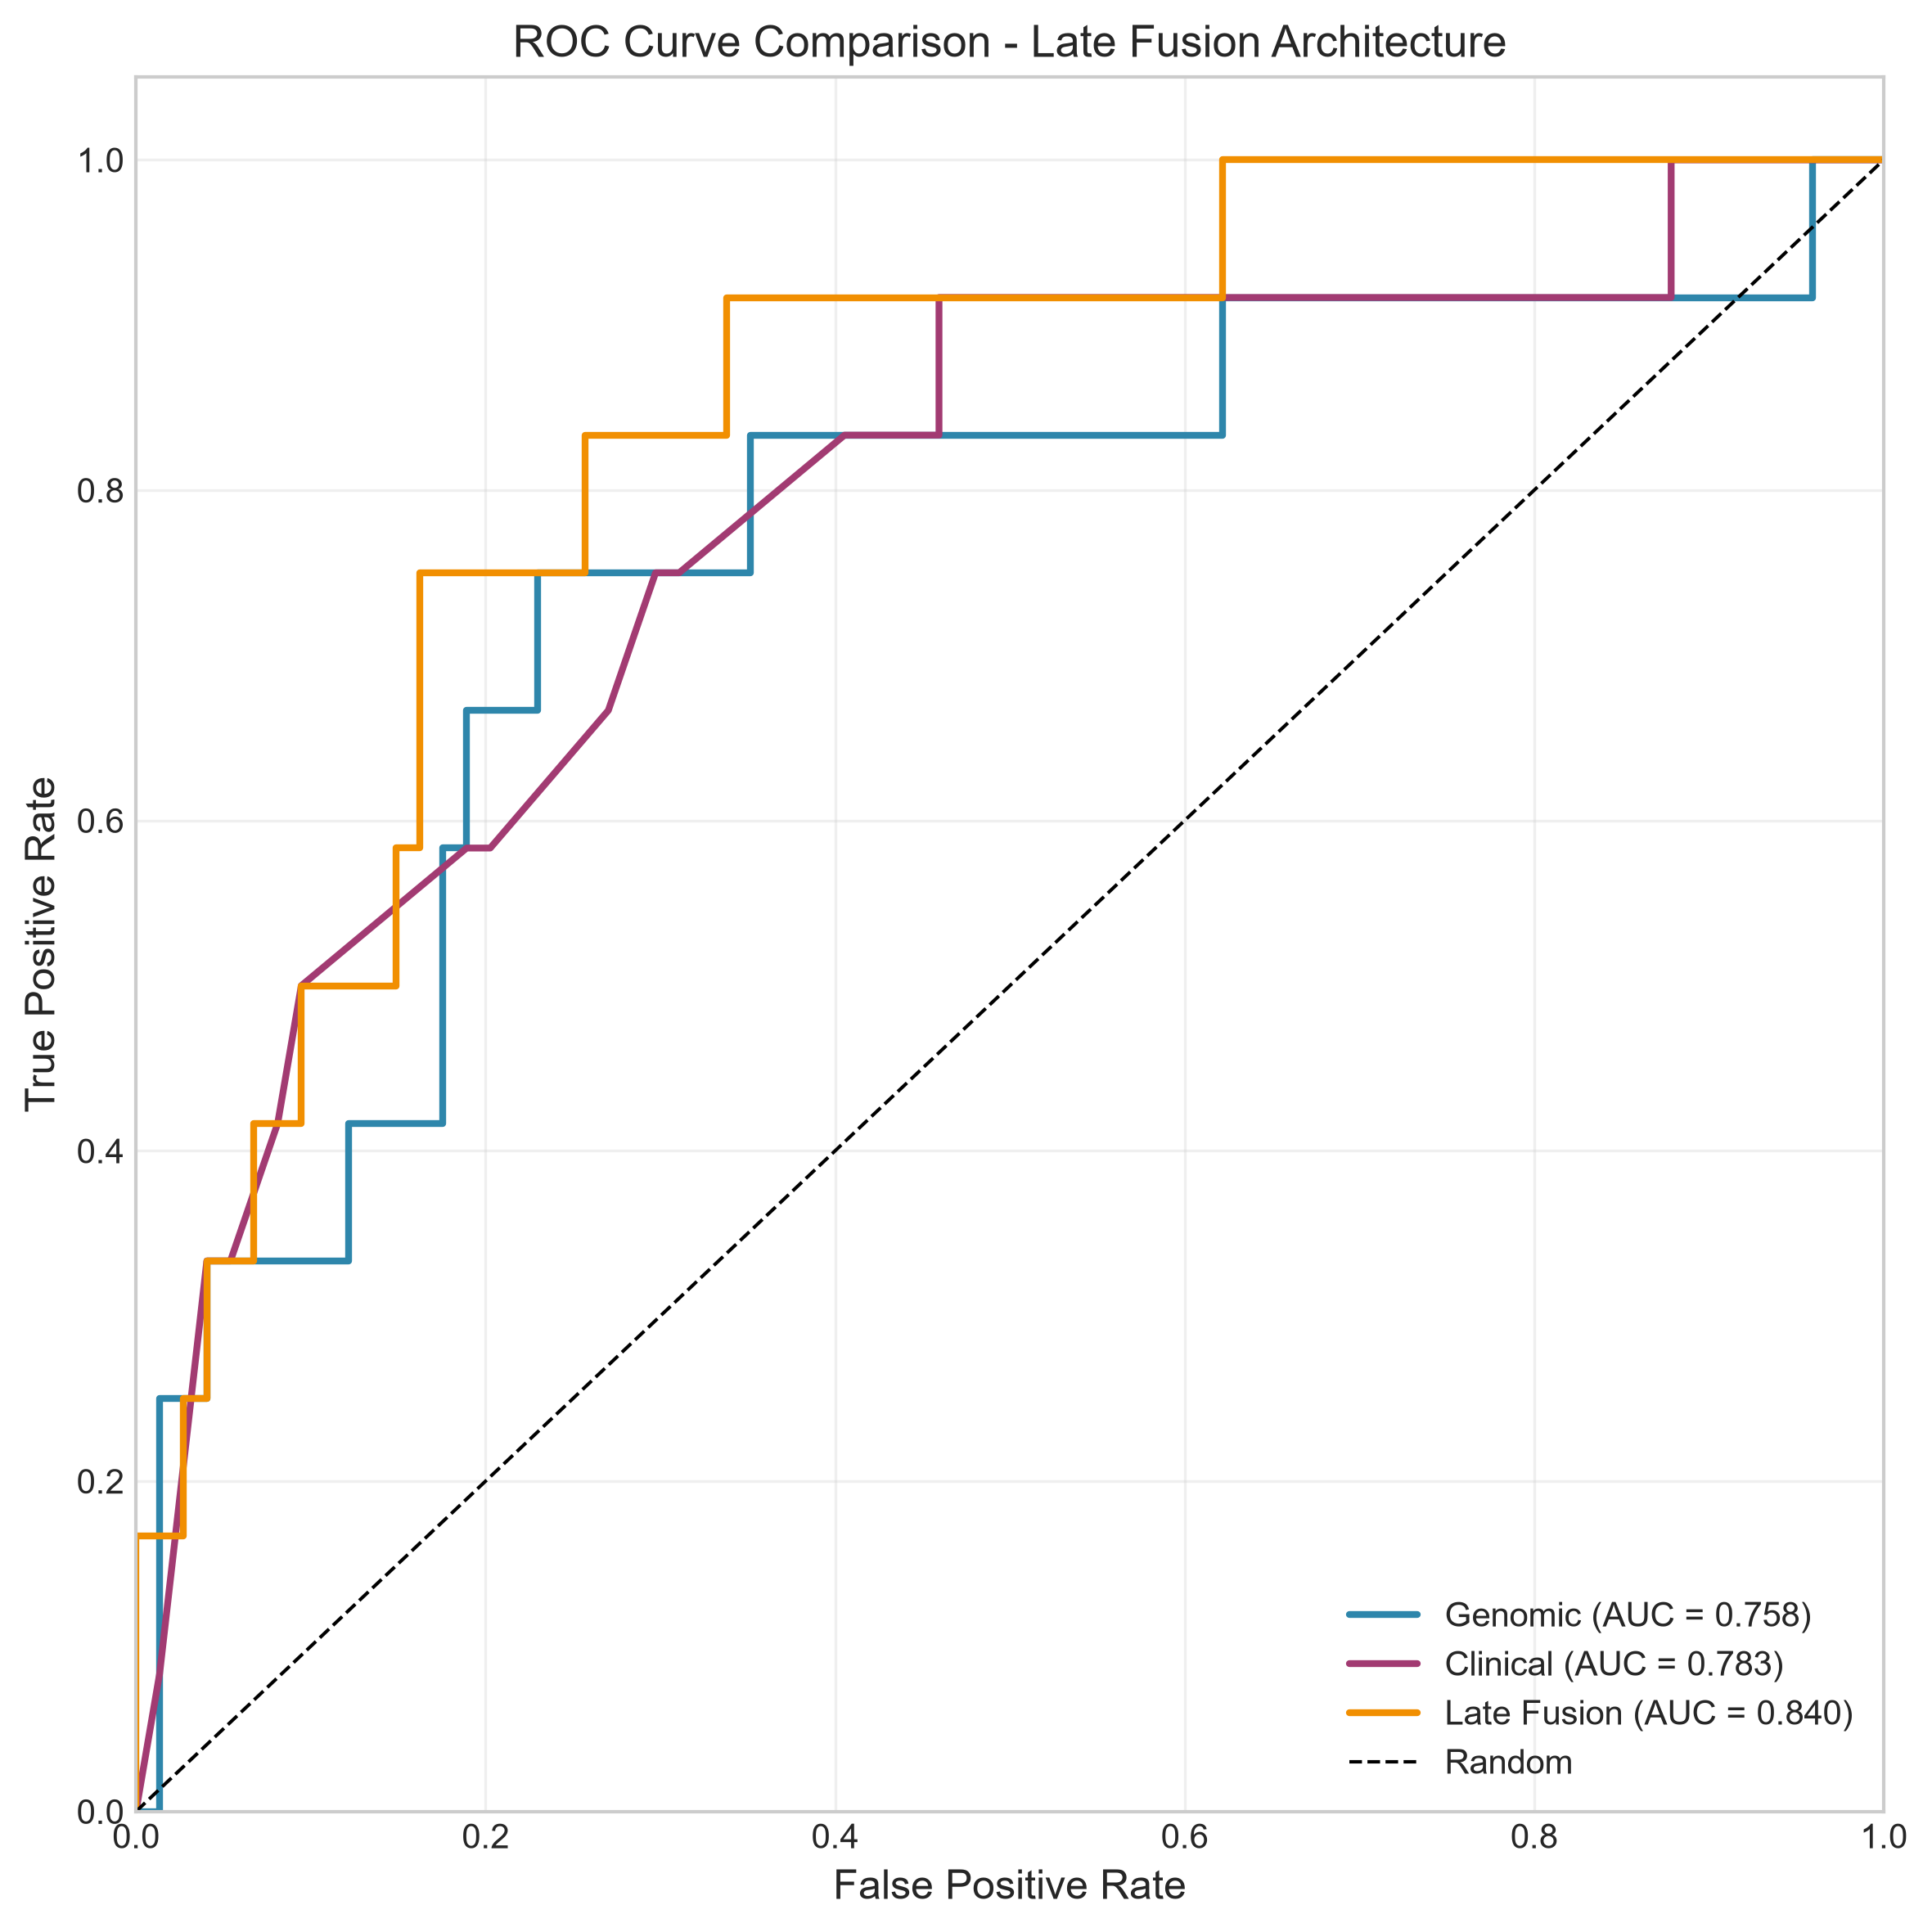

In [5]:
fpr_gen, tpr_gen, _ = roc_curve(y_test, y_prob_genomic)
fpr_clin, tpr_clin, _ = roc_curve(y_test, y_prob_clinical)
fpr_fus, tpr_fus, _ = roc_curve(y_test, y_prob_fusion)

auc_gen = auc(fpr_gen, tpr_gen)
auc_clin = auc(fpr_clin, tpr_clin)
auc_fus = auc(fpr_fus, tpr_fus)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(fpr_gen, tpr_gen, color='#2E86AB', lw=2, label=f'Genomic (AUC = {auc_gen:.3f})')
ax.plot(fpr_clin, tpr_clin, color='#A23B72', lw=2, label=f'Clinical (AUC = {auc_clin:.3f})')
ax.plot(fpr_fus, tpr_fus, color='#F18F01', lw=2, label=f'Late Fusion (AUC = {auc_fus:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison - Late Fusion Architecture')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, "roc_comparison.png")
plt.show()

## Step 4: Confusion Matrices

Optimal threshold: 0.3264


2026-09-11 19:18:57 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\final_confusion_matrix.png


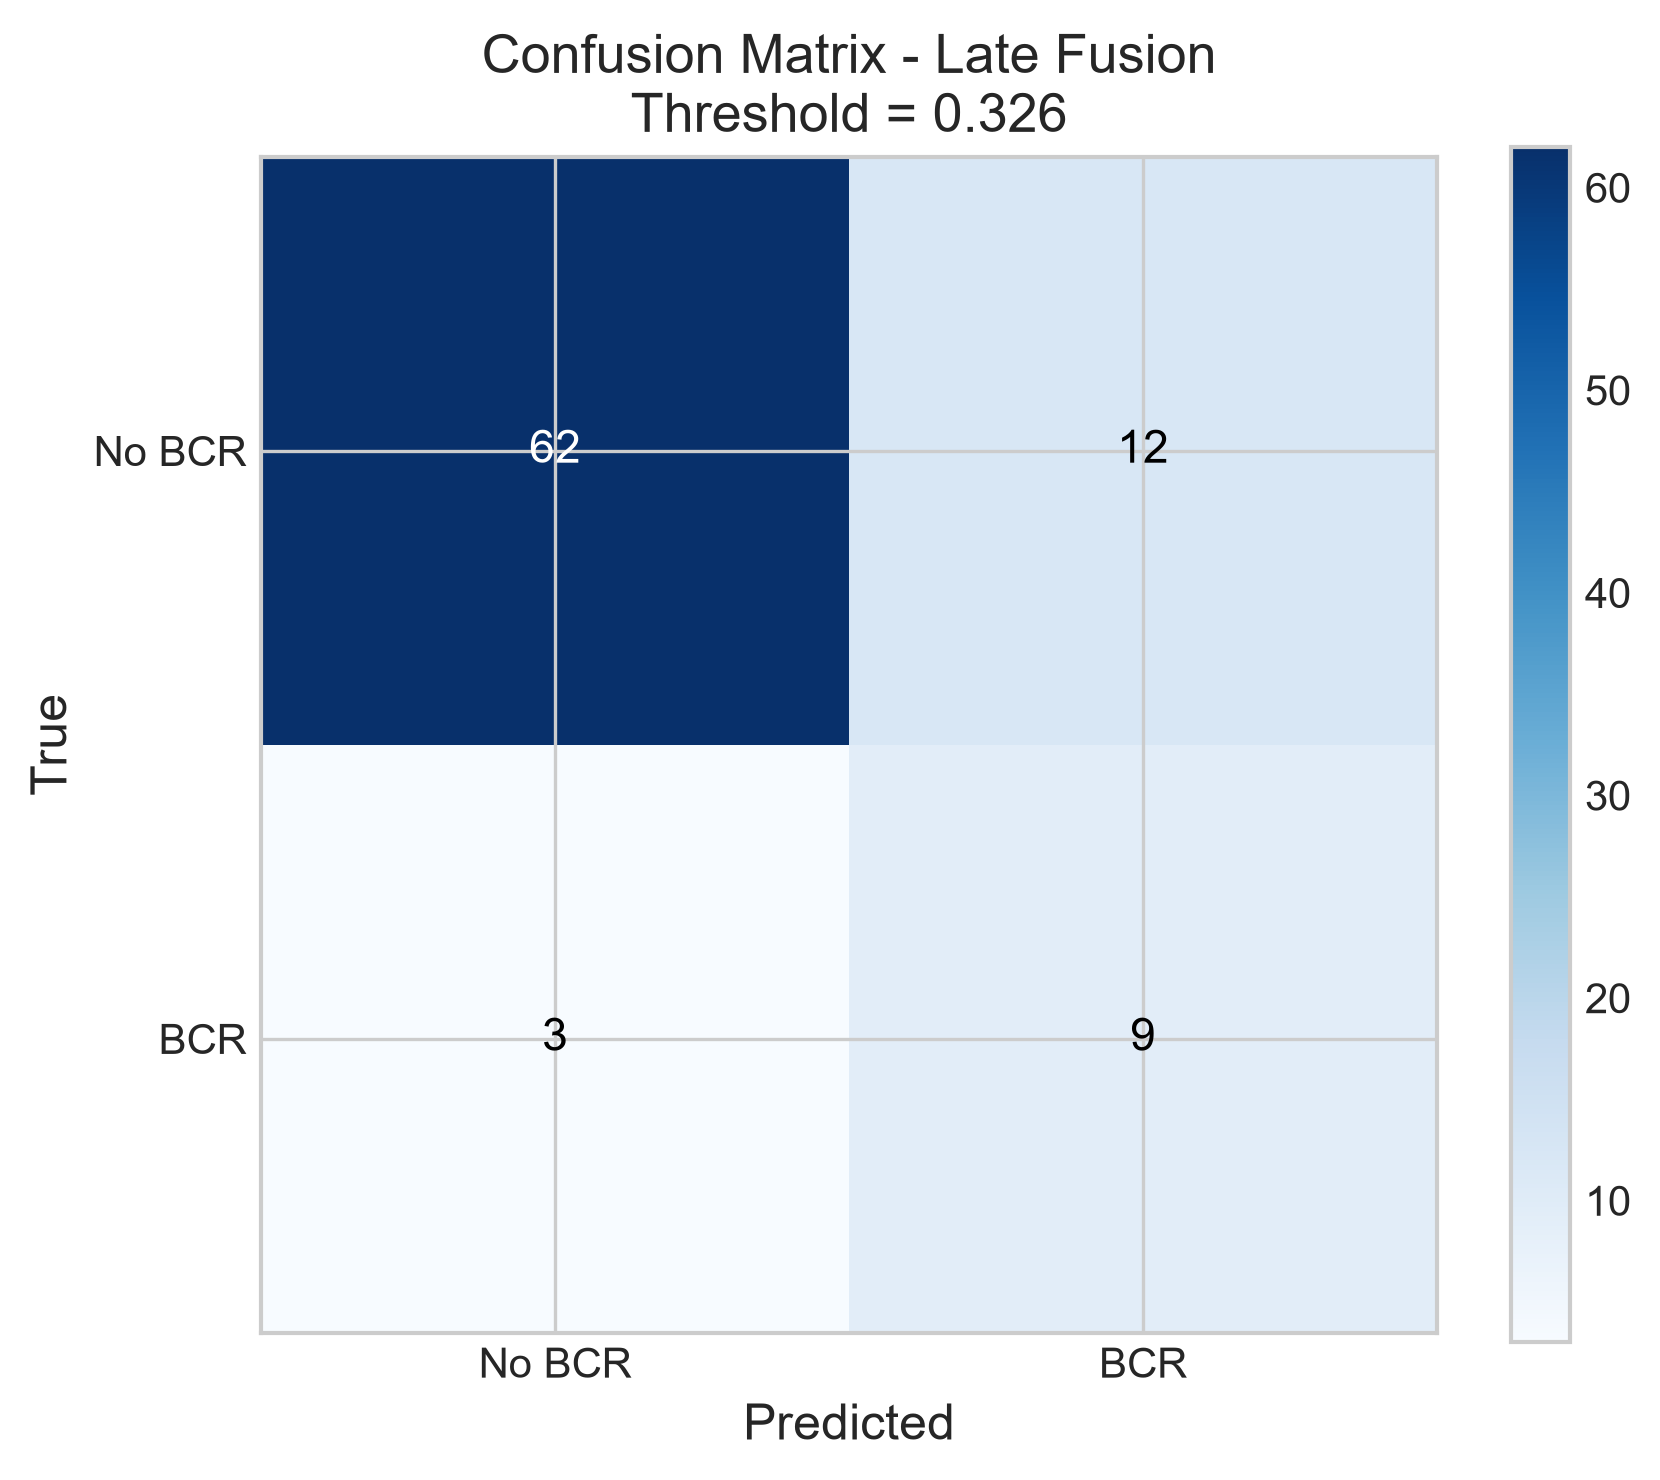


Classification Report:
              precision    recall  f1-score   support

      No BCR       0.95      0.84      0.89        74
         BCR       0.43      0.75      0.55        12

    accuracy                           0.83        86
   macro avg       0.69      0.79      0.72        86
weighted avg       0.88      0.83      0.84        86



In [6]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_fusion)
youden_j = tpr + (1 - fpr) - 1
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.4f}")

y_pred_fusion = (y_prob_fusion >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_fusion)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

classes = ['No BCR', 'BCR']
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix - Late Fusion\nThreshold = {optimal_threshold:.3f}')

thresh = cm.max() / 2.
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
save_figure(fig, "final_confusion_matrix.png")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_fusion, target_names=classes))

## Step 5: Model Comparison Bar Chart

2026-09-11 19:19:16 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\model_comparison.png


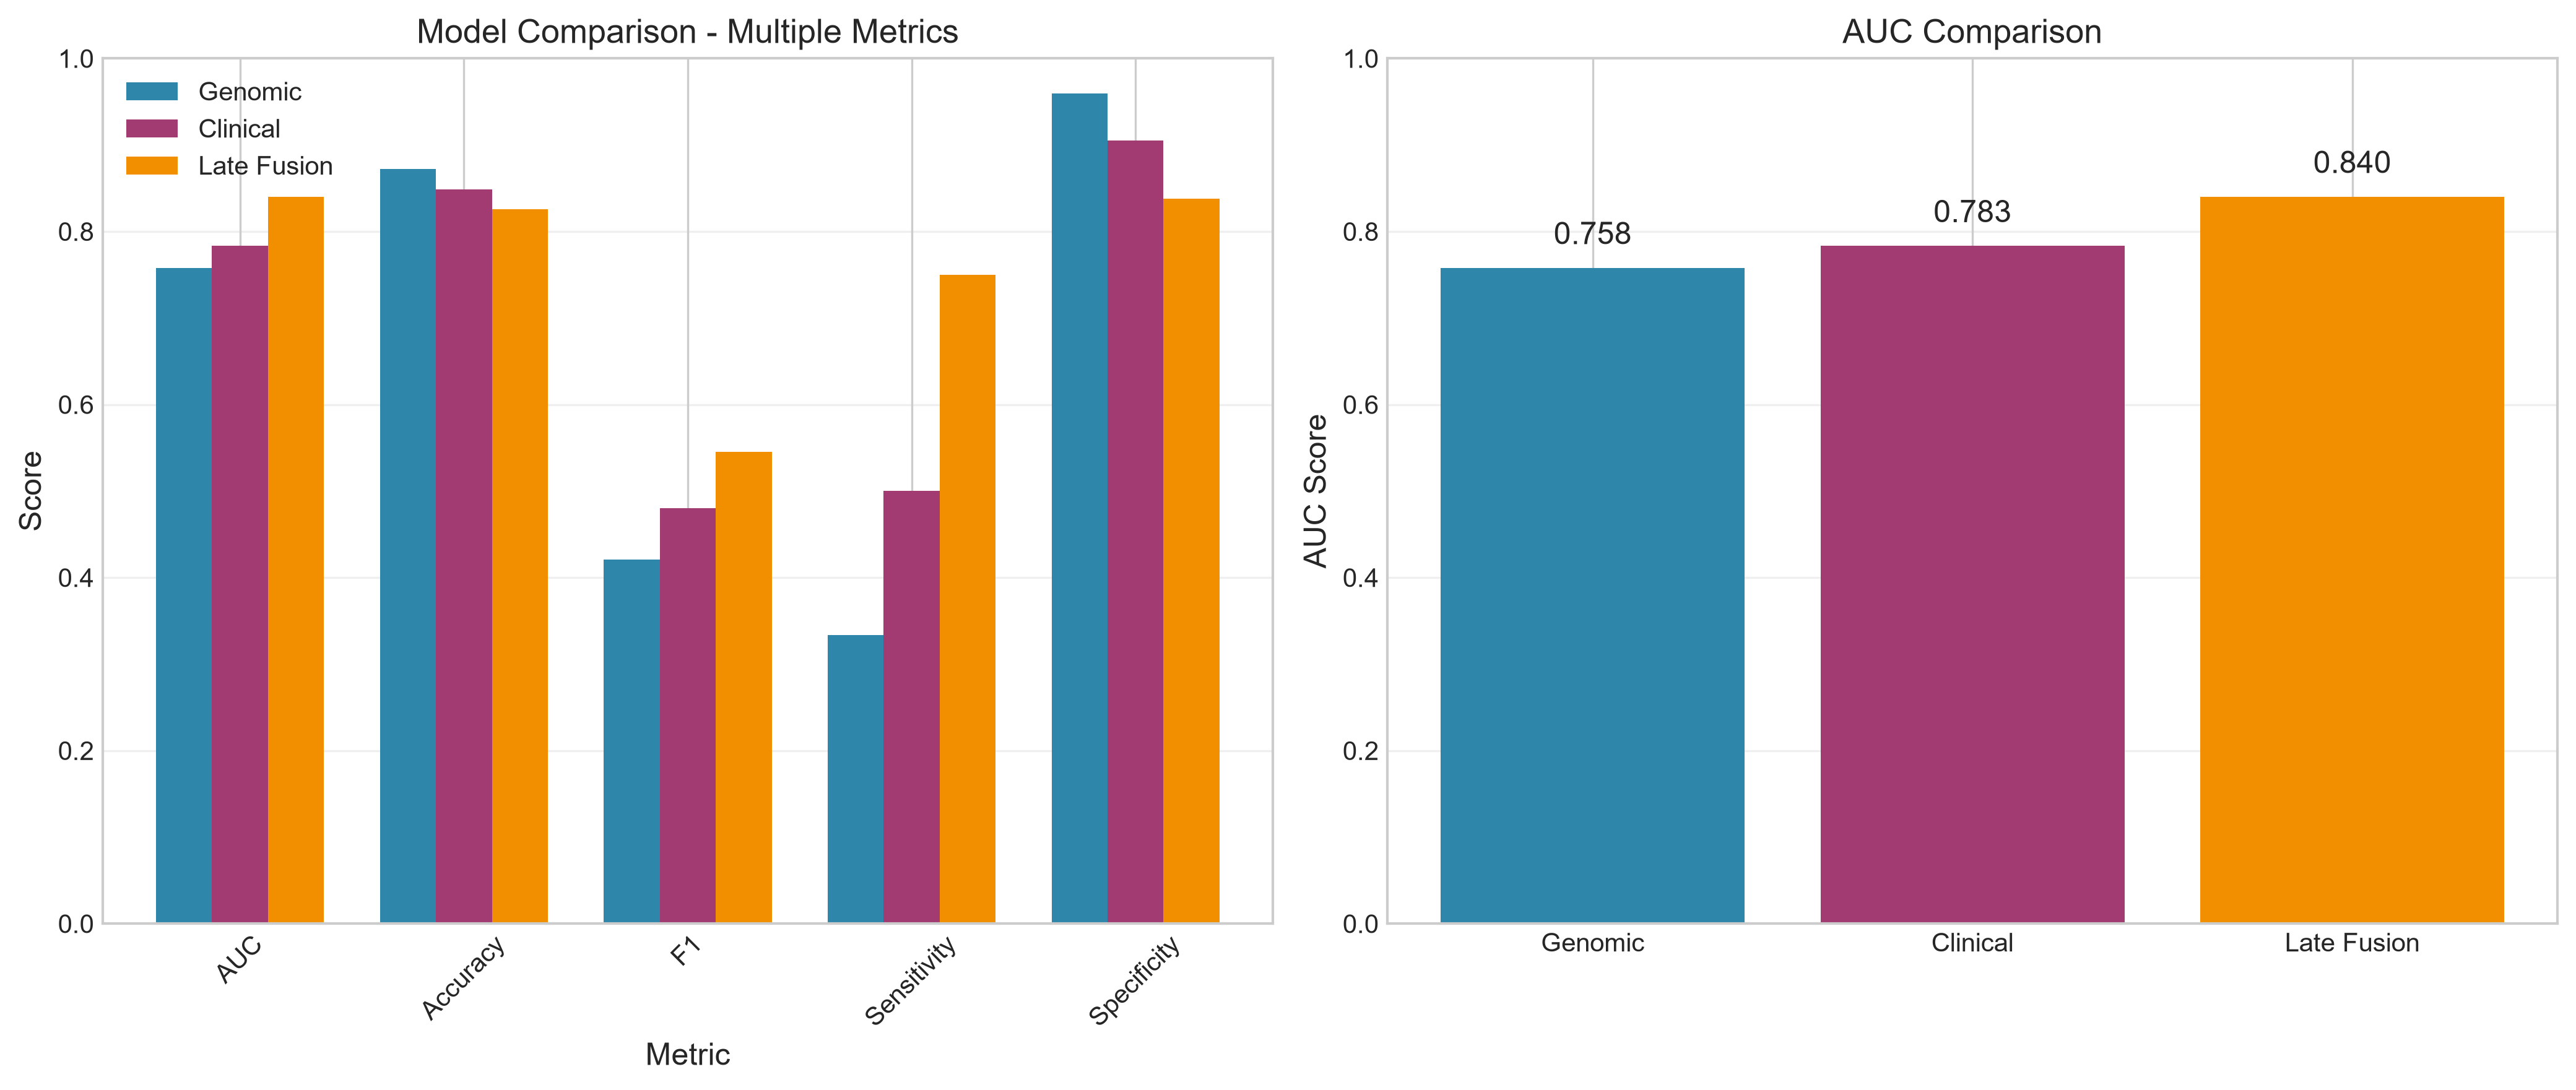

In [7]:
def compute_all_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'AUC': roc_auc_score(y_true, y_prob),
        'Accuracy': (tp + tn) / (tp + tn + fp + fn),
        'Precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'Recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'F1': 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0,
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
    }

metrics_gen = compute_all_metrics(y_test, y_prob_genomic)
metrics_clin = compute_all_metrics(y_test, y_prob_clinical)
metrics_fus = compute_all_metrics(y_test, y_prob_fusion, optimal_threshold)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics_to_show = ['AUC', 'Accuracy', 'F1', 'Sensitivity', 'Specificity']
x = np.arange(len(metrics_to_show))
width = 0.25

colors = ['#2E86AB', '#A23B72', '#F18F01']
models = ['Genomic', 'Clinical', 'Late Fusion']
all_metrics = [metrics_gen, metrics_clin, metrics_fus]

for i, (metrics, model, color) in enumerate(zip(all_metrics, models, colors)):
    values = [metrics[m] for m in metrics_to_show]
    axes[0].bar(x + i * width, values, width, label=model, color=color)

axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Comparison - Multiple Metrics')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_show, rotation=45)
axes[0].legend()
axes[0].set_ylim([0, 1.0])
axes[0].grid(axis='y', alpha=0.3)

auc_values = [metrics_gen['AUC'], metrics_clin['AUC'], metrics_fus['AUC']]
bars = axes[1].bar(models, auc_values, color=colors)
axes[1].set_ylabel('AUC Score')
axes[1].set_title('AUC Comparison')
axes[1].set_ylim([0, 1.0])
axes[1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, auc_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
save_figure(fig, "model_comparison.png")
plt.show()

## Step 6: Precision-Recall Curves

2026-09-11 19:19:29 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\final_pr_curve.png


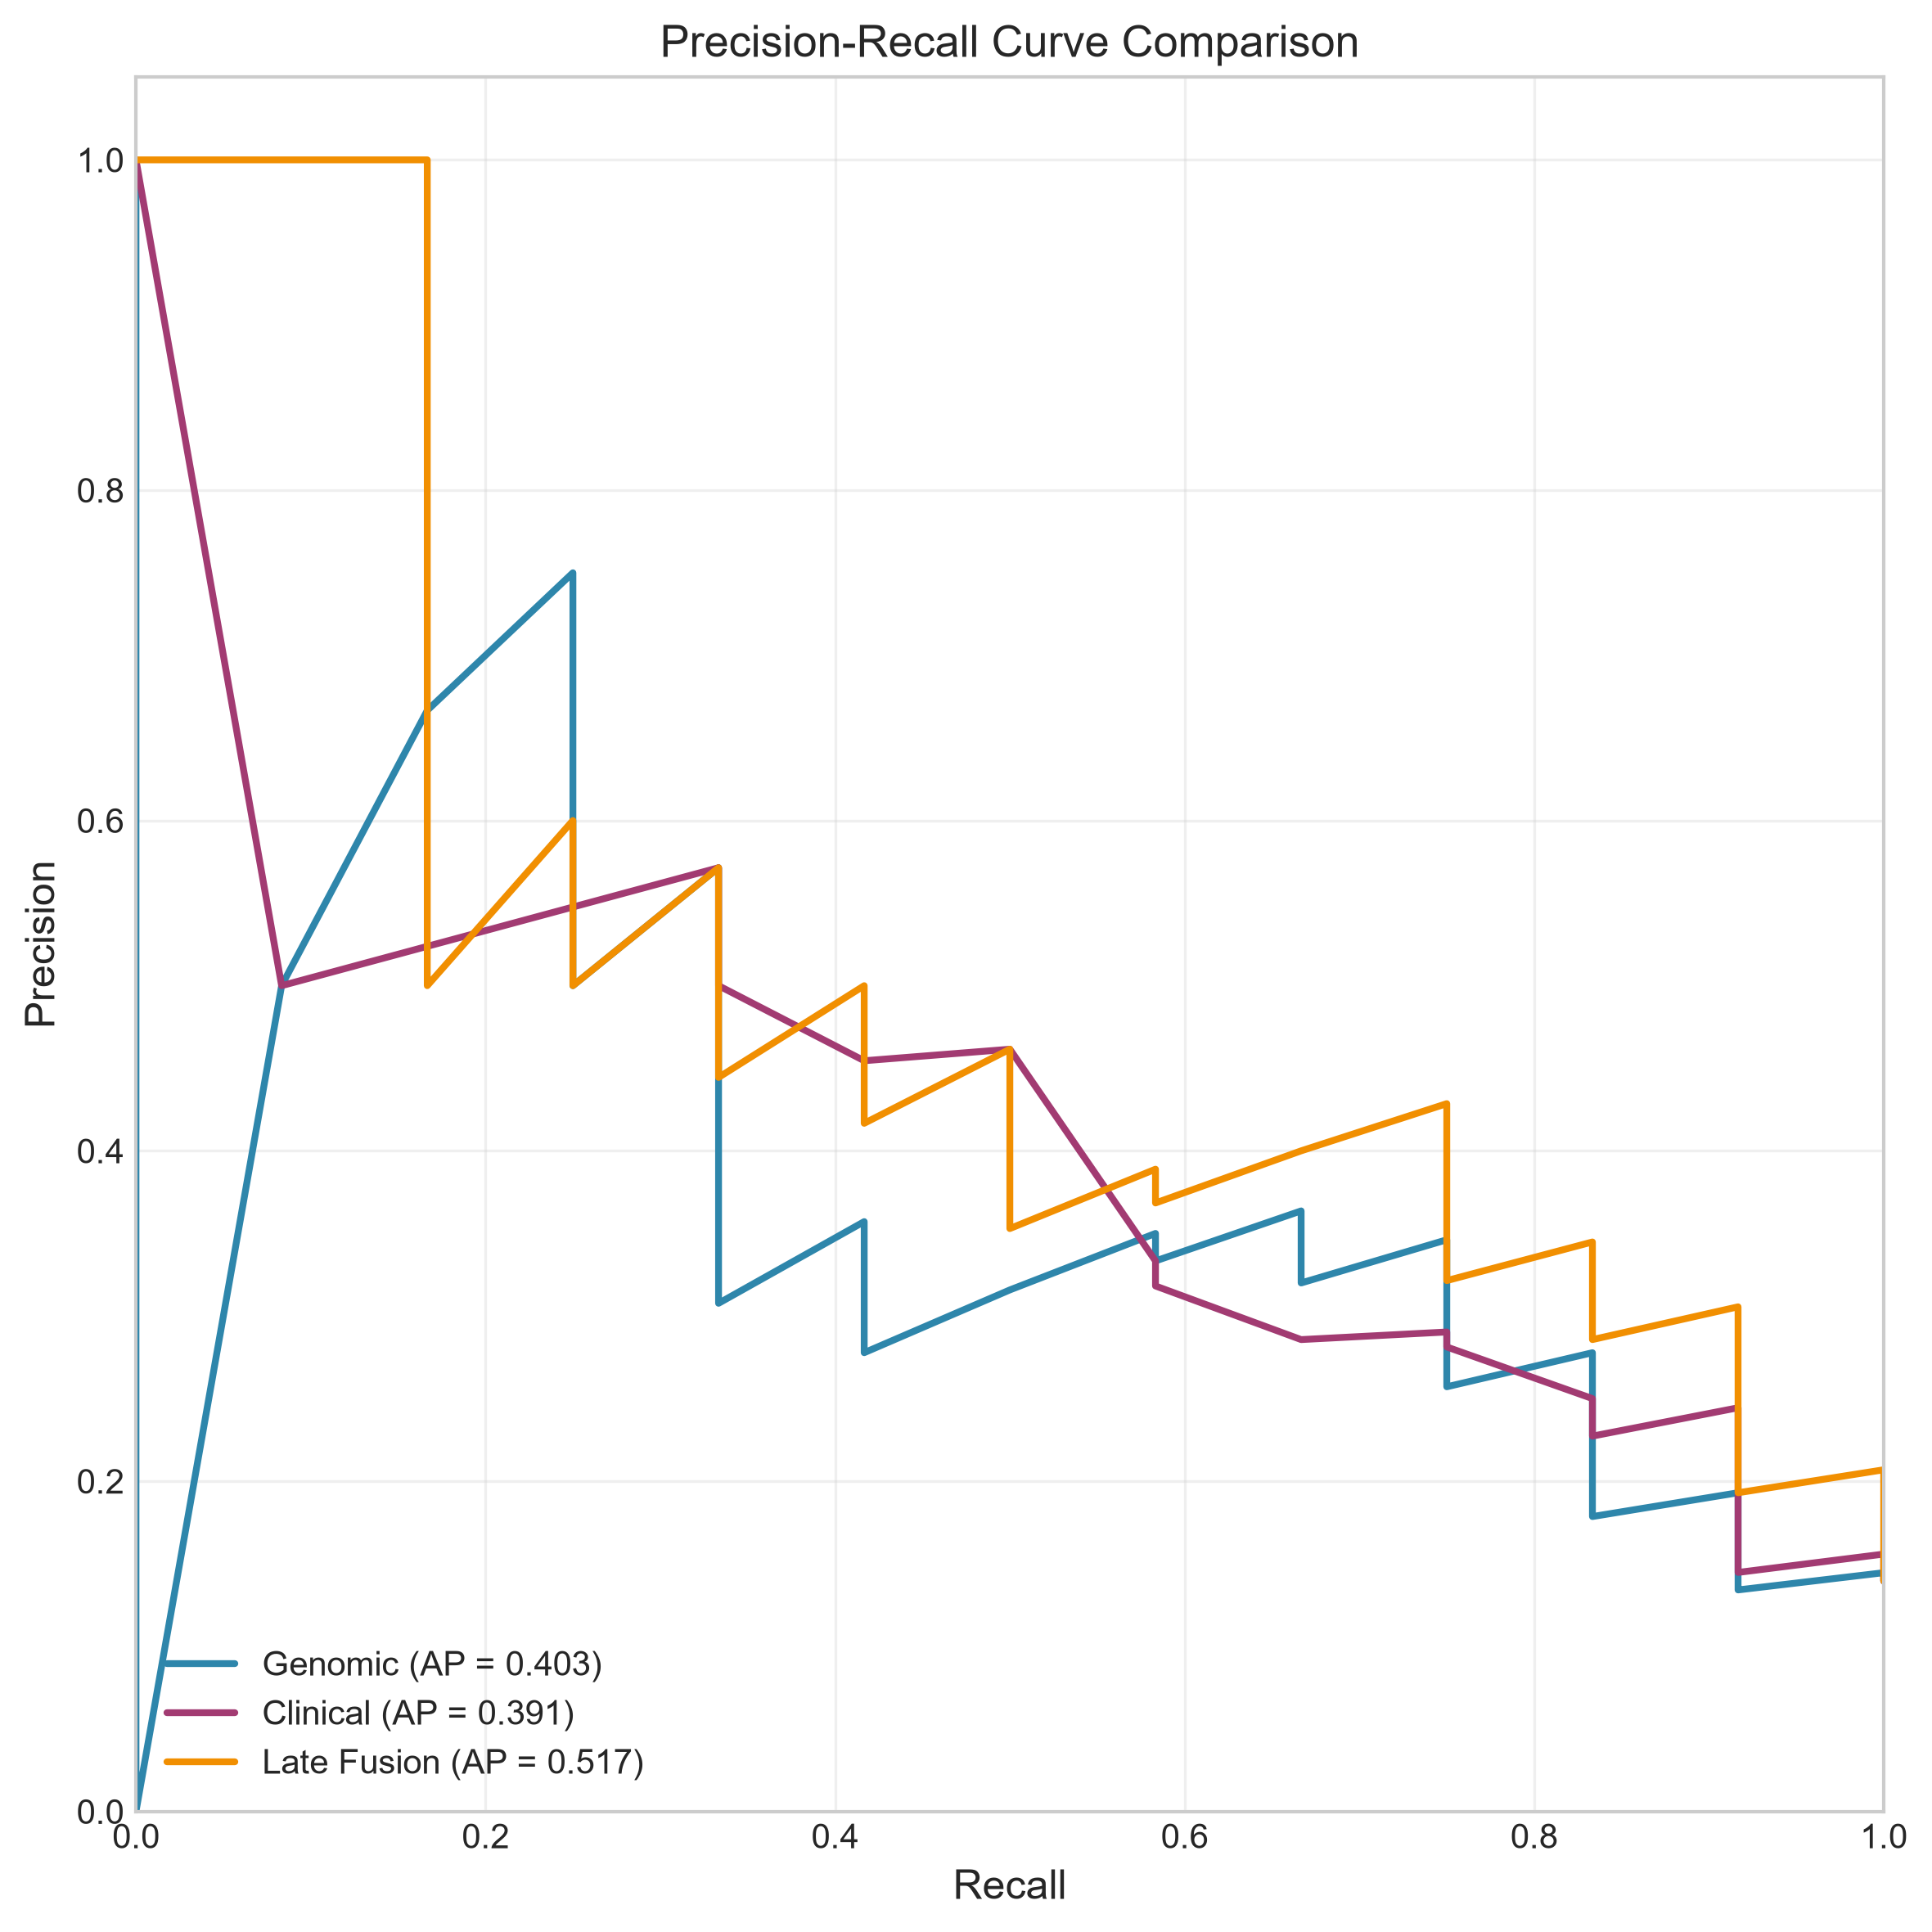

In [8]:
prec_gen, rec_gen, _ = precision_recall_curve(y_test, y_prob_genomic)
prec_clin, rec_clin, _ = precision_recall_curve(y_test, y_prob_clinical)
prec_fus, rec_fus, _ = precision_recall_curve(y_test, y_prob_fusion)

ap_gen = average_precision_score(y_test, y_prob_genomic)
ap_clin = average_precision_score(y_test, y_prob_clinical)
ap_fus = average_precision_score(y_test, y_prob_fusion)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(rec_gen, prec_gen, color='#2E86AB', lw=2, label=f'Genomic (AP = {ap_gen:.3f})')
ax.plot(rec_clin, prec_clin, color='#A23B72', lw=2, label=f'Clinical (AP = {ap_clin:.3f})')
ax.plot(rec_fus, prec_fus, color='#F18F01', lw=2, label=f'Late Fusion (AP = {ap_fus:.3f})')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve Comparison')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, "final_pr_curve.png")
plt.show()

## Step 7: Calibration Plot

2026-09-11 19:19:44 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\final_calibration_plot.png


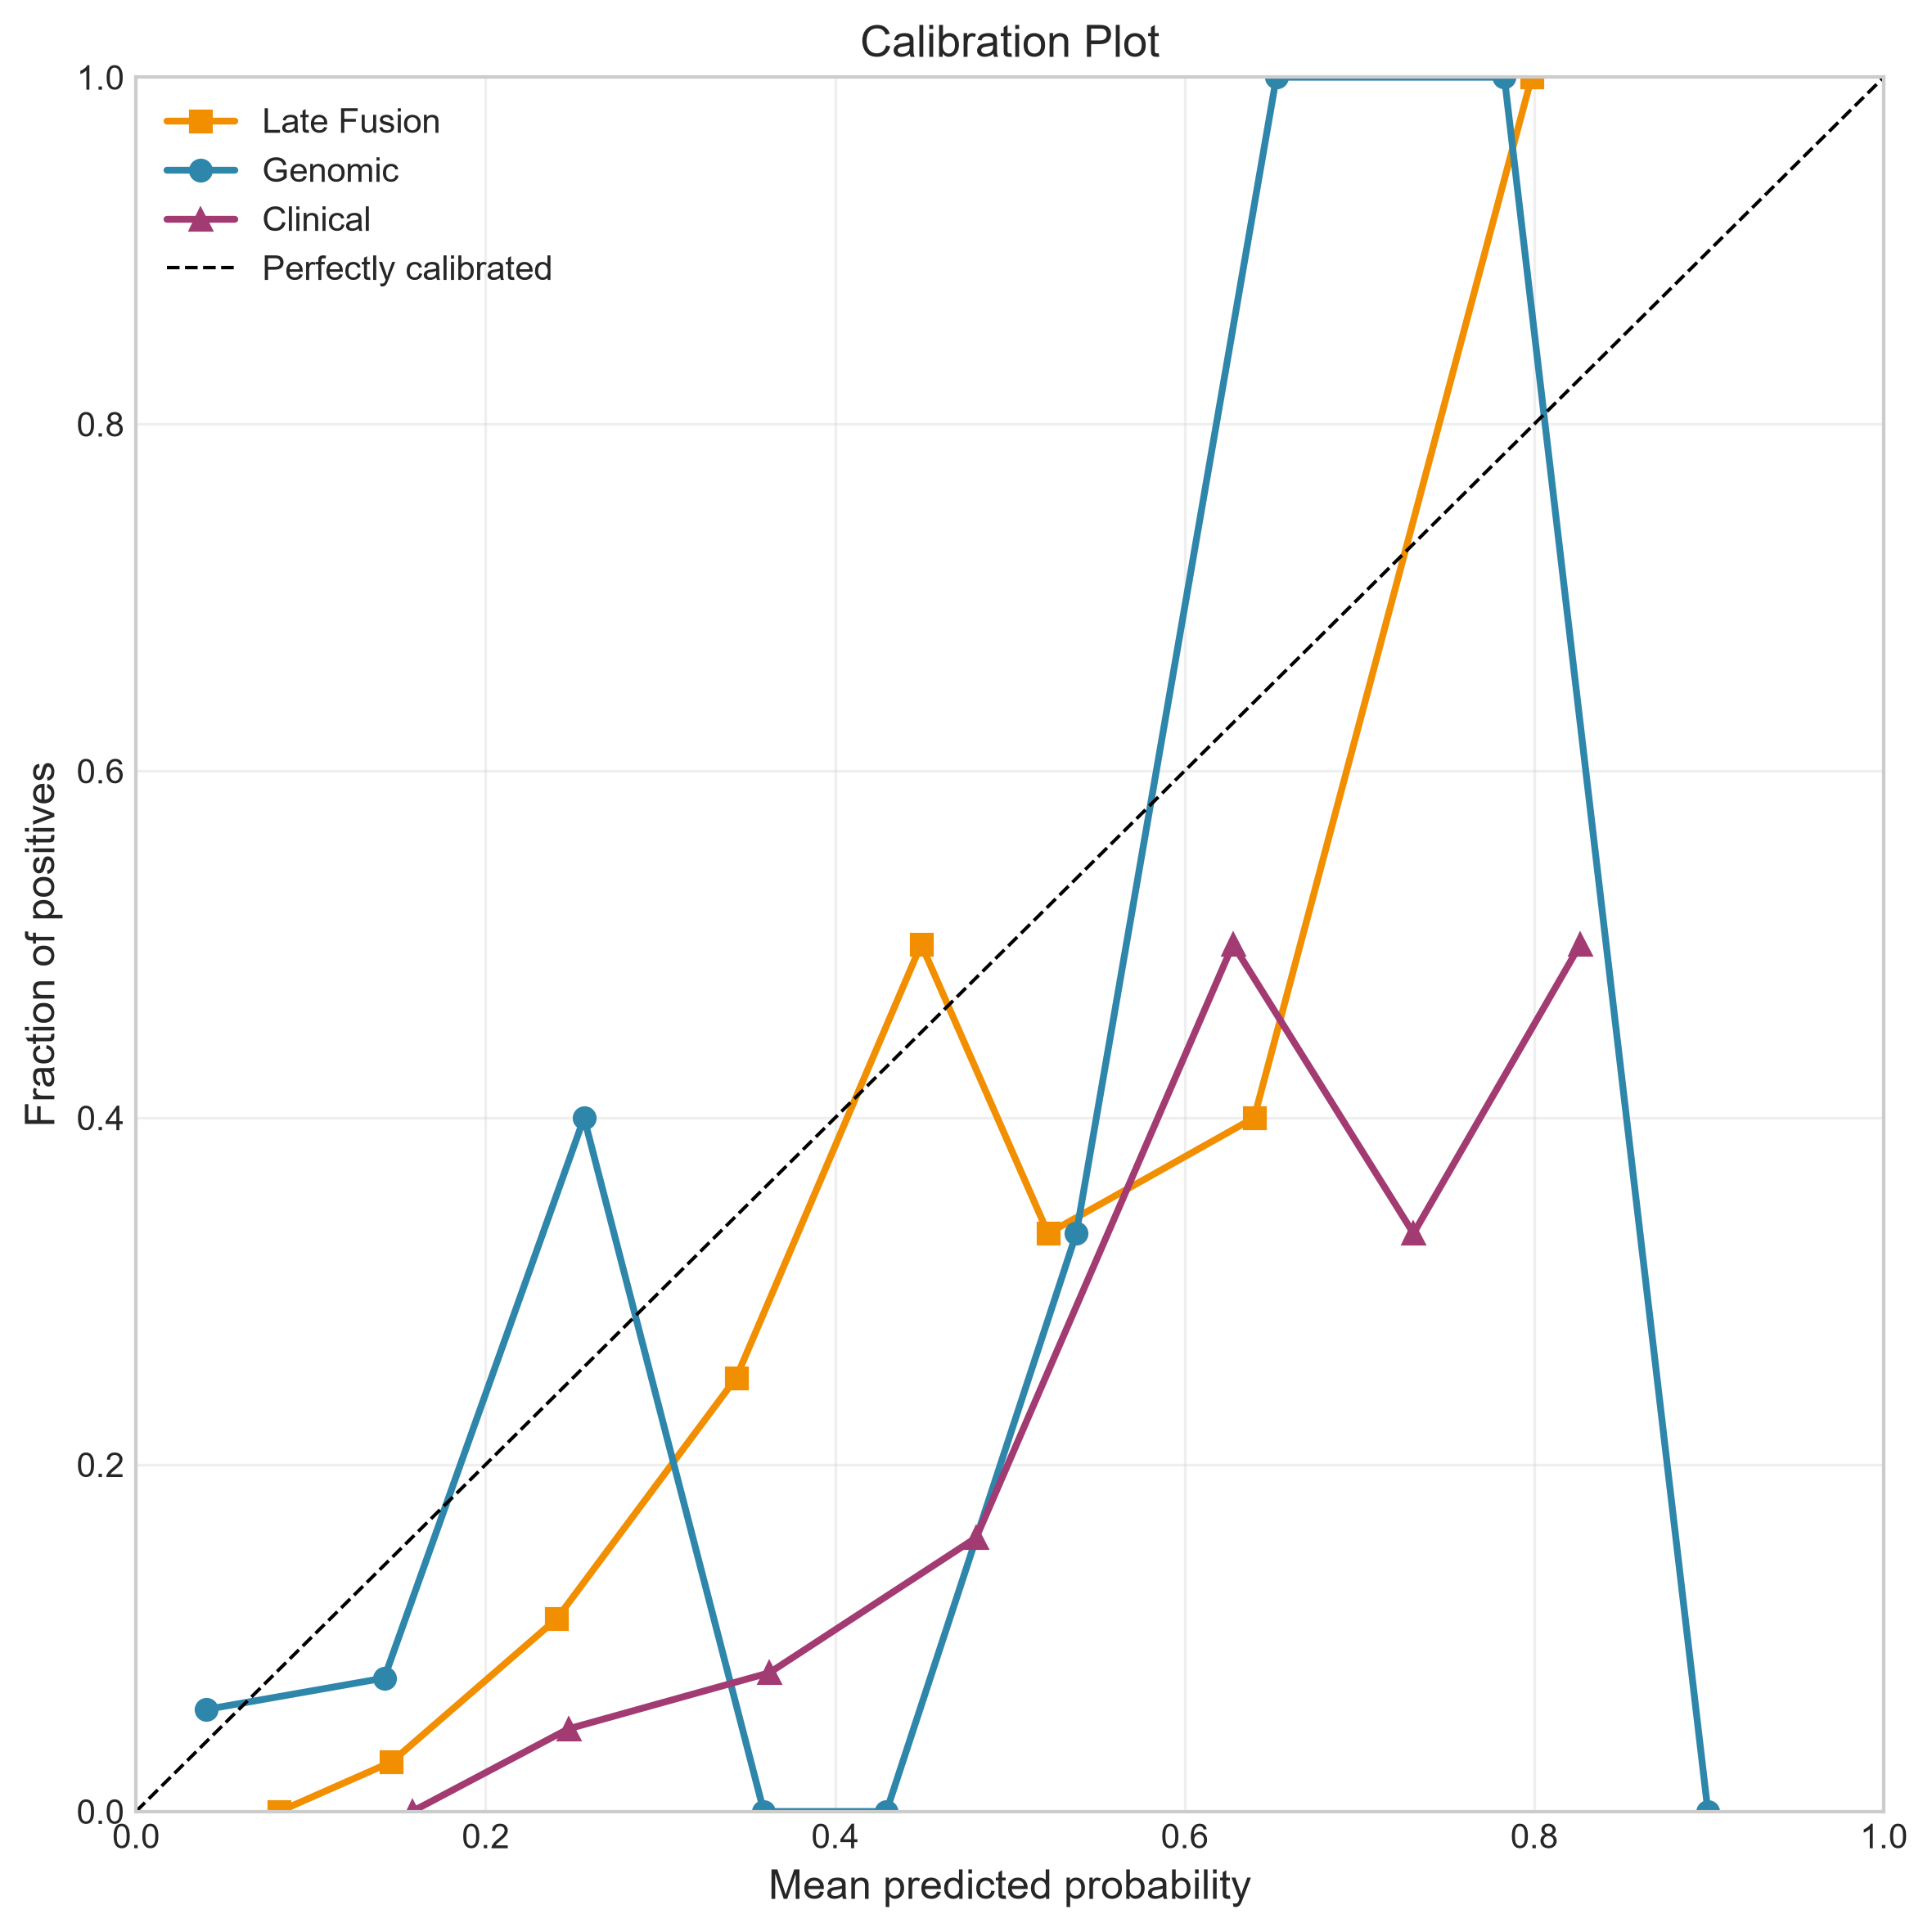

In [9]:
from sklearn.calibration import calibration_curve

prob_true_fus, prob_pred_fus = calibration_curve(y_test, y_prob_fusion, n_bins=10)
prob_true_gen, prob_pred_gen = calibration_curve(y_test, y_prob_genomic, n_bins=10)
prob_true_clin, prob_pred_clin = calibration_curve(y_test, y_prob_clinical, n_bins=10)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(prob_pred_fus, prob_true_fus, 's-', color='#F18F01', lw=2, label='Late Fusion')
ax.plot(prob_pred_gen, prob_true_gen, 'o-', color='#2E86AB', lw=2, label='Genomic')
ax.plot(prob_pred_clin, prob_true_clin, '^-', color='#A23B72', lw=2, label='Clinical')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfectly calibrated')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Plot')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, "final_calibration_plot.png")
plt.show()

## Step 8: Save Final Results

In [10]:
final_results = {
    'genomic': metrics_gen,
    'clinical': metrics_clin,
    'late_fusion': metrics_fus,
    'fusion_weights': {
        'genomic': float(fusion_predictor.genomic_weight),
        'clinical': float(fusion_predictor.clinical_weight)
    },
    'optimal_threshold': float(optimal_threshold),
    'test_samples': int(len(y_test)),
}

with open(config.TABLES_DIR / "final_evaluation.json", 'w') as f:
    json.dump(final_results, f, indent=2)

results_df = pd.DataFrame({
    'Model': ['Genomic', 'Clinical', 'Late Fusion'],
    'AUC': [metrics_gen['AUC'], metrics_clin['AUC'], metrics_fus['AUC']],
    'Accuracy': [metrics_gen['Accuracy'], metrics_clin['Accuracy'], metrics_fus['Accuracy']],
    'Precision': [metrics_gen['Precision'], metrics_clin['Precision'], metrics_fus['Precision']],
    'Recall': [metrics_gen['Recall'], metrics_clin['Recall'], metrics_fus['Recall']],
    'F1': [metrics_gen['F1'], metrics_clin['F1'], metrics_fus['F1']],
    'Sensitivity': [metrics_gen['Sensitivity'], metrics_clin['Sensitivity'], metrics_fus['Sensitivity']],
    'Specificity': [metrics_gen['Specificity'], metrics_clin['Specificity'], metrics_fus['Specificity']],
})
results_df.to_csv(config.TABLES_DIR / "final_evaluation.csv", index=False)

print("Final results saved to outputs/tables/")
print("\nSummary:")
print(results_df.to_string(index=False))

Final results saved to outputs/tables/

Summary:
      Model      AUC  Accuracy  Precision   Recall       F1  Sensitivity  Specificity
    Genomic 0.757883  0.872093   0.571429 0.333333 0.421053     0.333333     0.959459
   Clinical 0.783221  0.848837   0.461538 0.500000 0.480000     0.500000     0.905405
Late Fusion 0.840090  0.825581   0.428571 0.750000 0.545455     0.750000     0.837838
